
Model Performance Summary
      Model  Accuracy  Precision  Recall  F1 Score
0   XGBoost     77.50       0.71    0.62      0.66
1  CatBoost     78.71       0.73    0.64      0.68
2  LightGBM     78.82       0.73    0.64      0.68


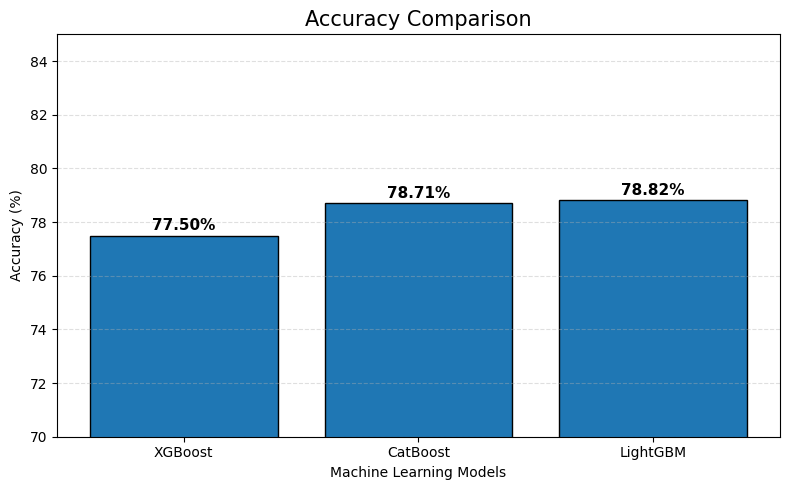

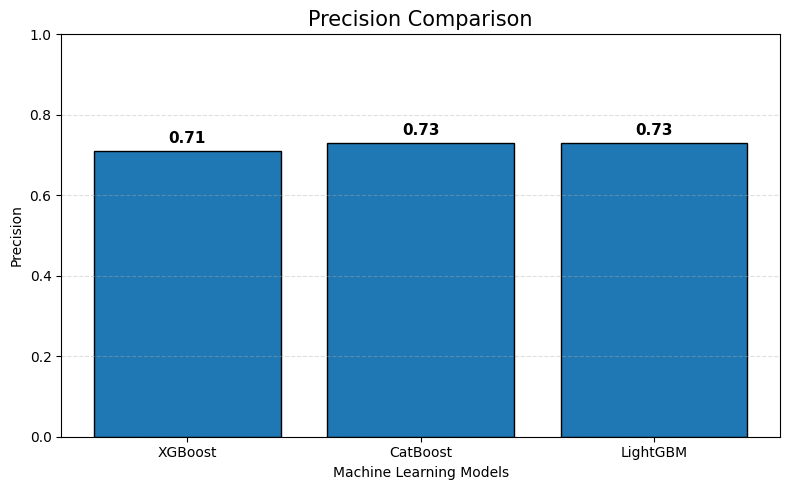

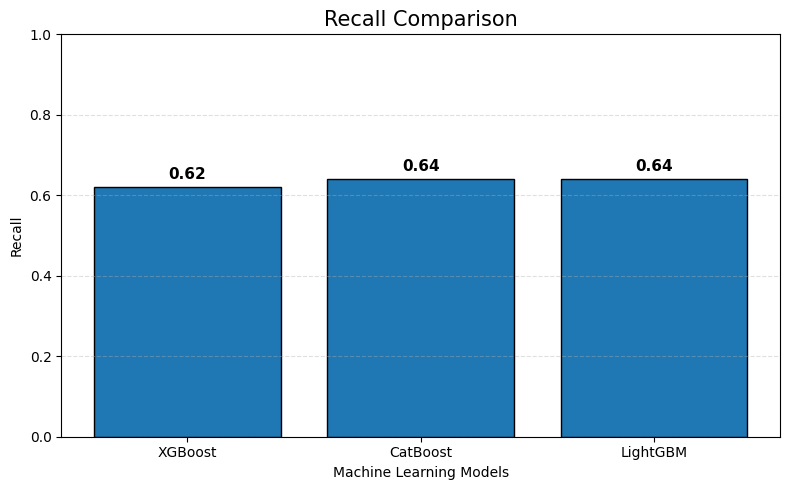

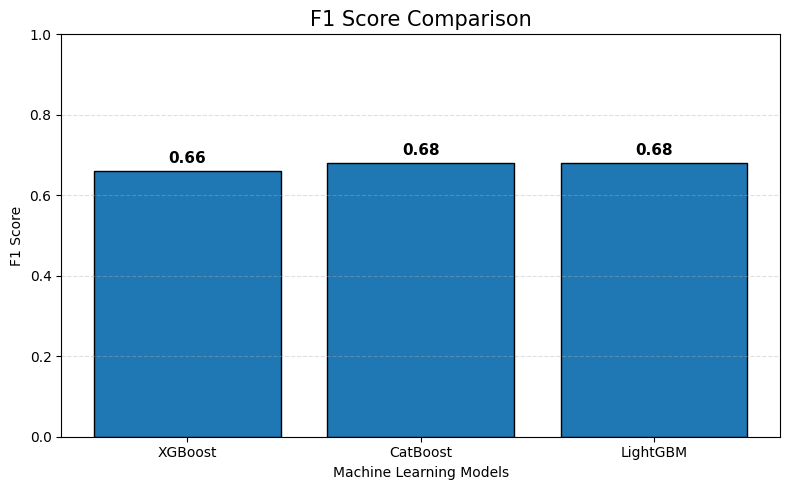

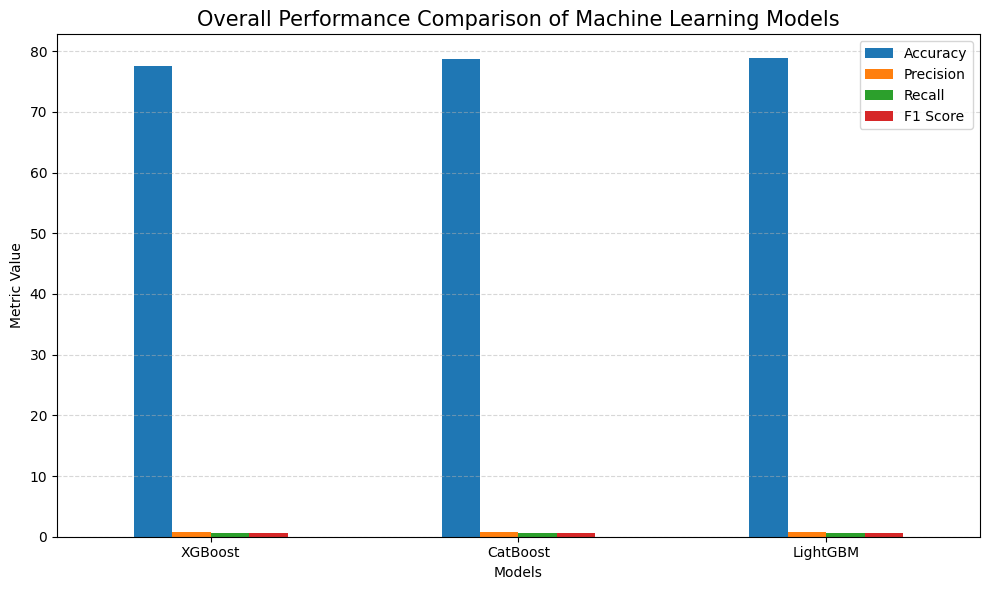


FINAL MODEL SELECTION
Selected Model : LightGBM
Accuracy       : 78.82%
Precision      : 0.73
Recall         : 0.64
F1 Score       : 0.68

Reason for Selection:
- Highest prediction accuracy
- Balanced Precision and Recall
- Strong F1 Score
- Suitable for employee promotion prediction
- Efficient and scalable for HR Analytics applications

Analysis Completed Successfully
Outputs saved in: Model_Analysis_Results


In [1]:
# ==========================================================
# HR Analytics - Model Performance Analysis & Visualization
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

# ----------------------------------------------------------
# Create folder to save outputs
# ----------------------------------------------------------

output_folder = "Model_Analysis_Results"

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# ----------------------------------------------------------
# Model Performance Data
# ----------------------------------------------------------

results = pd.DataFrame({

    "Model": ["XGBoost", "CatBoost", "LightGBM"],

    "Accuracy": [77.50, 78.71, 78.82],

    "Precision": [0.71, 0.73, 0.73],

    "Recall": [0.62, 0.64, 0.64],

    "F1 Score": [0.66, 0.68, 0.68]

})

print("\n==============================")
print("Model Performance Summary")
print("==============================")
print(results)

# ----------------------------------------------------------
# Save CSV
# ----------------------------------------------------------

results.to_csv(
    os.path.join(output_folder, "Final_Model_Comparison.csv"),
    index=False
)

# ----------------------------------------------------------
# Function to create bar charts
# ----------------------------------------------------------

def create_bar_chart(metric, ylabel):

    plt.figure(figsize=(8,5))

    bars = plt.bar(
        results["Model"],
        results[metric],
        edgecolor='black'
    )

    plt.title(f"{metric} Comparison", fontsize=15)

    plt.xlabel("Machine Learning Models")

    plt.ylabel(ylabel)

    if metric == "Accuracy":
        plt.ylim(70,85)
    else:
        plt.ylim(0,1)

    plt.grid(axis='y', linestyle='--', alpha=0.4)

    for bar in bars:

        value = bar.get_height()

        if metric == "Accuracy":
            label = f"{value:.2f}%"
            offset = 0.20
        else:
            label = f"{value:.2f}"
            offset = 0.02

        plt.text(
            bar.get_x()+bar.get_width()/2,
            value+offset,
            label,
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

    plt.tight_layout()

    plt.savefig(
        os.path.join(output_folder, f"{metric.replace(' ','_')}.png"),
        dpi=300
    )

    plt.show()

# ----------------------------------------------------------
# Generate Individual Charts
# ----------------------------------------------------------

create_bar_chart("Accuracy", "Accuracy (%)")

create_bar_chart("Precision", "Precision")

create_bar_chart("Recall", "Recall")

create_bar_chart("F1 Score", "F1 Score")

# ----------------------------------------------------------
# Overall Comparison Chart
# ----------------------------------------------------------

comparison = results.set_index("Model")

plt.figure(figsize=(10,6))

comparison.plot(
    kind="bar",
    ax=plt.gca()
)

plt.title("Overall Performance Comparison of Machine Learning Models", fontsize=15)

plt.xlabel("Models")

plt.ylabel("Metric Value")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(loc='best')

plt.tight_layout()

plt.savefig(
    os.path.join(output_folder, "Overall_Model_Comparison.png"),
    dpi=300
)

plt.show()

# ----------------------------------------------------------
# Best Model Selection
# ----------------------------------------------------------

best_model = results.loc[results["Accuracy"].idxmax()]

print("\n========================================")
print("FINAL MODEL SELECTION")
print("========================================")
print(f"Selected Model : {best_model['Model']}")
print(f"Accuracy       : {best_model['Accuracy']:.2f}%")
print(f"Precision      : {best_model['Precision']:.2f}")
print(f"Recall         : {best_model['Recall']:.2f}")
print(f"F1 Score       : {best_model['F1 Score']:.2f}")

print("\nReason for Selection:")
print("- Highest prediction accuracy")
print("- Balanced Precision and Recall")
print("- Strong F1 Score")
print("- Suitable for employee promotion prediction")
print("- Efficient and scalable for HR Analytics applications")

print("\n========================================")
print("Analysis Completed Successfully")
print("Outputs saved in:", output_folder)
print("========================================")